# Experiment No. 2 — Exploratory Data Analysis (EDA) on a Real-World Business Dataset

**Dataset used:** Sample Superstore Dataset (US retail orders — Sales, Profit, Discount, Quantity across Regions, Categories and Customer Segments)

**Aim:** To perform EDA using Python to understand the dataset's structure, identify trends, detect anomalies, analyze feature relationships, and generate business insights.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('superstore.csv', encoding='latin1')
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%m/%d/%Y')
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164


## Step 3: Explore the dataset — dimensions, data types, summary statistics

In [2]:
print("Shape (rows, columns):", df.shape)
print()
df.info()


Shape (rows, columns): (10800, 21)

<class 'pandas.DataFrame'>
RangeIndex: 10800 entries, 0 to 10799
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         10800 non-null  str           
 1   Order ID       10800 non-null  str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9983 non-null   float64       
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           

In [3]:
df.describe()


,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994,9994,9983.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,2017-04-30 05:17:08.056834,2017-05-04 04:17:20.304182,55245.233297,229.858001,3.789574,0.156203,28.656896
min,2015-01-03 00:00:00,2015-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2016-05-23 00:00:00,2016-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,2017-06-26 00:00:00,2017-06-29 00:00:00,57103.000000,54.490000,3.000000,0.200000,8.666500
75%,2018-05-14 00:00:00,2018-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,2018-12-30 00:00:00,2019-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,NaN,NaN,32038.715955,623.245101,2.225110,0.206452,234.260108


In [4]:
# Missing values
df.isnull().sum()


Row ID             0
Order ID           0
Order Date       806
Ship Date        806
Ship Mode        806
Customer ID      806
Customer Name    806
Segment          806
Country          806
City             806
State            806
Postal Code      817
Region           806
Product ID       806
Category         806
Sub-Category     806
Product Name     806
Sales            806
Quantity         806
Discount         806
Profit           806
dtype: int64

In [5]:
# Categorical value counts
print(df['Category'].value_counts())
print()
print(df['Segment'].value_counts())
print()
print(df['Region'].value_counts())


Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64

Segment
Consumer       5191
Corporate      3020
Home Office    1783
Name: count, dtype: int64

Region
West       3203
East       2848
Central    2323
South      1620
Name: count, dtype: int64


## Step 4: Distribution of numerical features (histograms & density plots)

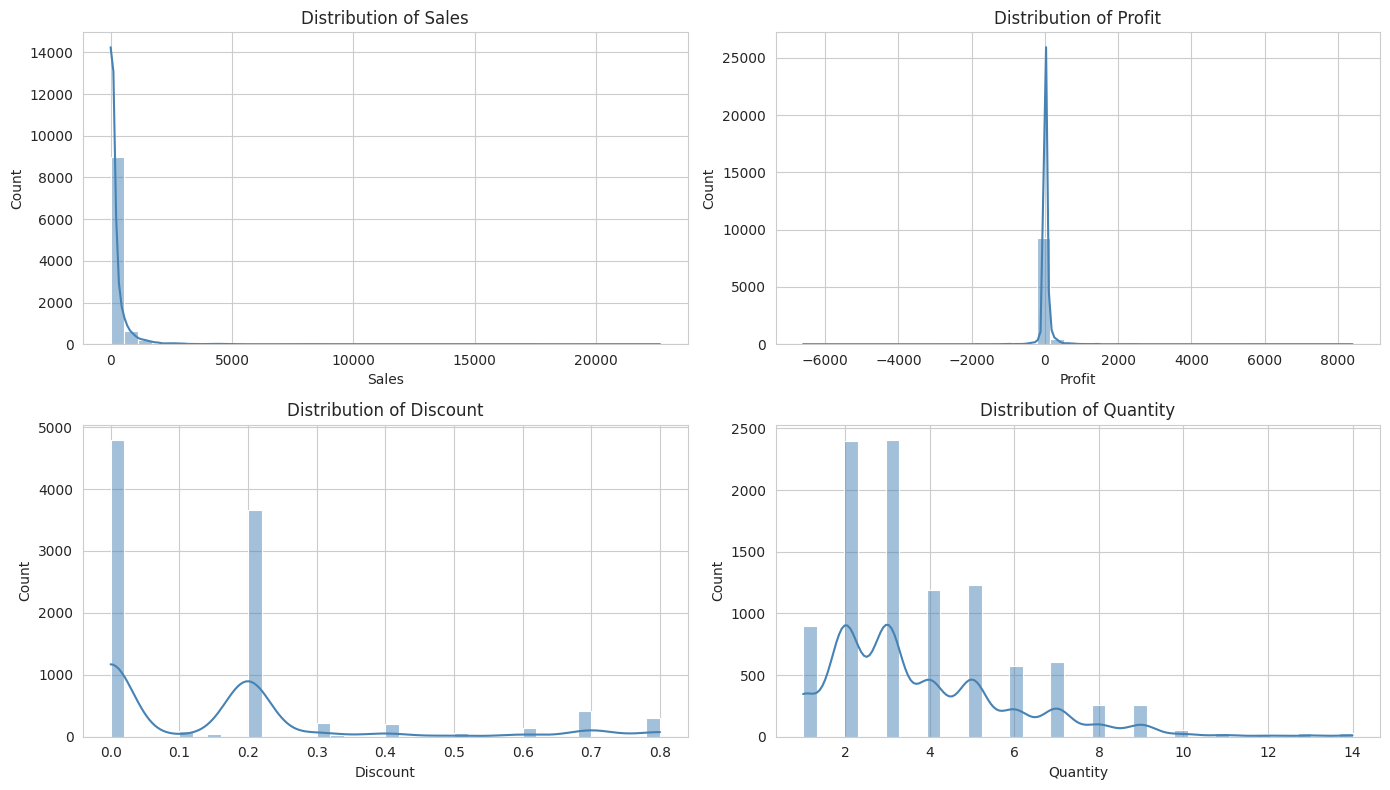

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.flatten(), ['Sales', 'Profit', 'Discount', 'Quantity']):
    sns.histplot(df[col], kde=True, ax=ax, bins=40, color='steelblue')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.savefig('dist_numerical.png', dpi=120)
plt.show()


**Observation:** Sales and Profit are heavily right-skewed with a long tail of large orders;
Profit also has a cluster of negative values (loss-making orders). Discount is concentrated at a
few standard levels (0, 0.2, 0.3 ...) rather than being continuous, and Quantity is discrete and
mostly small (1–7 units per line item).

## Step 5: Categorical variables — bar charts & count plots

/tmp/ipykernel_513/3034163144.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Category', ax=axes[0], palette='viridis')
/tmp/ipykernel_513/3034163144.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Segment', ax=axes[1], palette='mako')
/tmp/ipykernel_513/3034163144.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Region', ax=axes[2], palette='rocket')


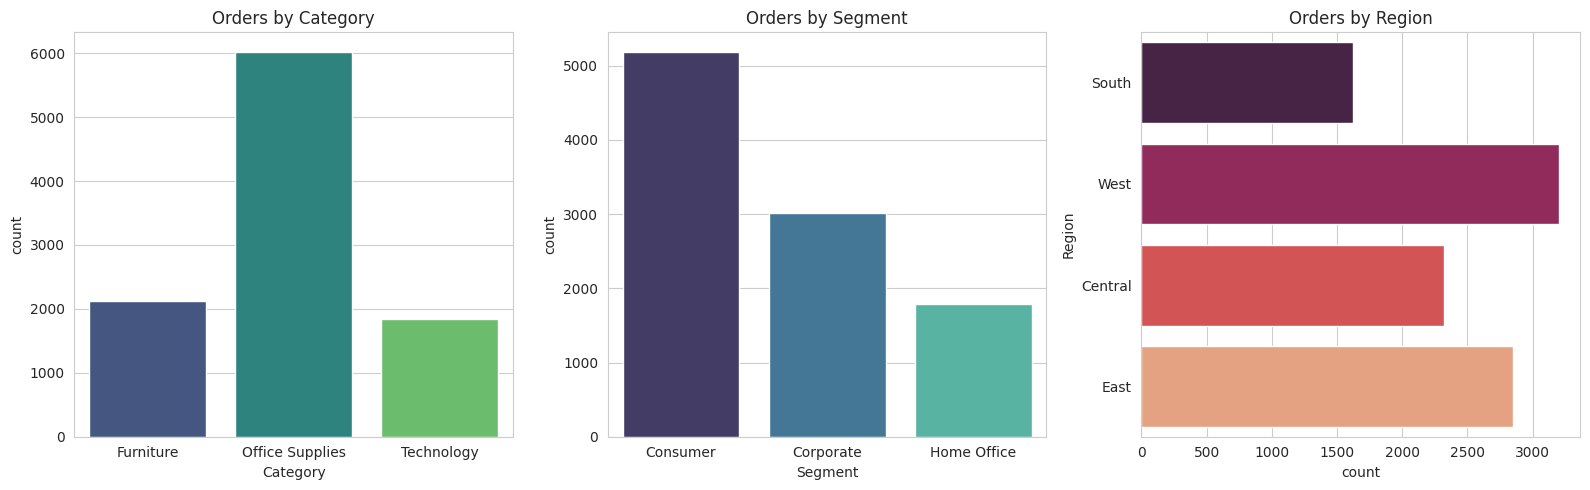

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.countplot(data=df, x='Category', ax=axes[0], palette='viridis')
axes[0].set_title('Orders by Category')

sns.countplot(data=df, x='Segment', ax=axes[1], palette='mako')
axes[1].set_title('Orders by Segment')

sns.countplot(data=df, y='Region', ax=axes[2], palette='rocket')
axes[2].set_title('Orders by Region')
plt.tight_layout()
plt.savefig('categorical_counts.png', dpi=120)
plt.show()


/tmp/ipykernel_513/3577682906.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_subcats.values, y=top_subcats.index, palette='crest')


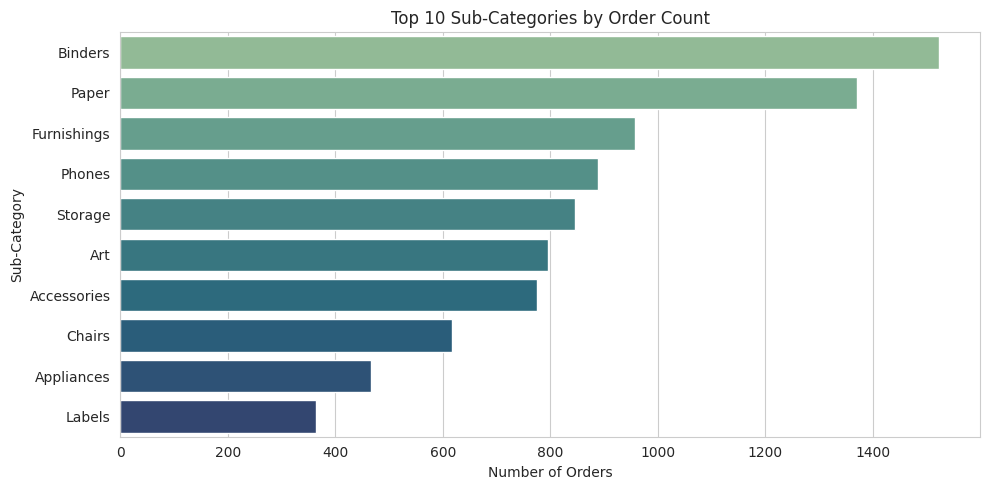

In [8]:
top_subcats = df['Sub-Category'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_subcats.values, y=top_subcats.index, palette='crest')
plt.title('Top 10 Sub-Categories by Order Count')
plt.xlabel('Number of Orders')
plt.tight_layout()
plt.savefig('top_subcategories.png', dpi=120)
plt.show()


**Observation:** Office Supplies dominates order volume, followed by Furniture and Technology.
The Consumer segment places the most orders, and the West and East regions lead in order count
over Central and South.

## Step 6: Correlation matrix and heatmap

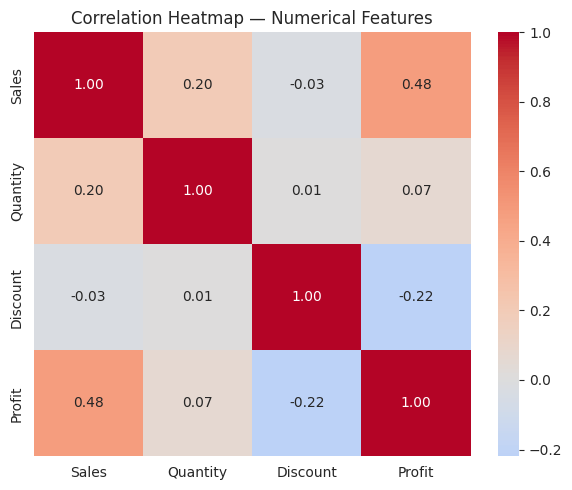

,Sales,Quantity,Discount,Profit
Sales,1.000000,0.200795,-0.028190,0.479064
Quantity,0.200795,1.000000,0.008623,0.066253
Discount,-0.028190,0.008623,1.000000,-0.219487
Profit,0.479064,0.066253,-0.219487,1.000000


In [9]:
num_cols = ['Sales', 'Quantity', 'Discount', 'Profit']
corr = df[num_cols].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap — Numerical Features')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=120)
plt.show()
corr


**Observation:** Sales and Profit have a weak positive correlation — bigger orders don't
reliably mean bigger profit. Discount shows a negative correlation with Profit, meaning heavier
discounting erodes margins. Quantity has only a mild relationship with Sales and Profit.

## Step 7: Box plots & scatter plots — outliers and relationships

/tmp/ipykernel_513/1182237003.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Category', y='Profit', palette='Set2')


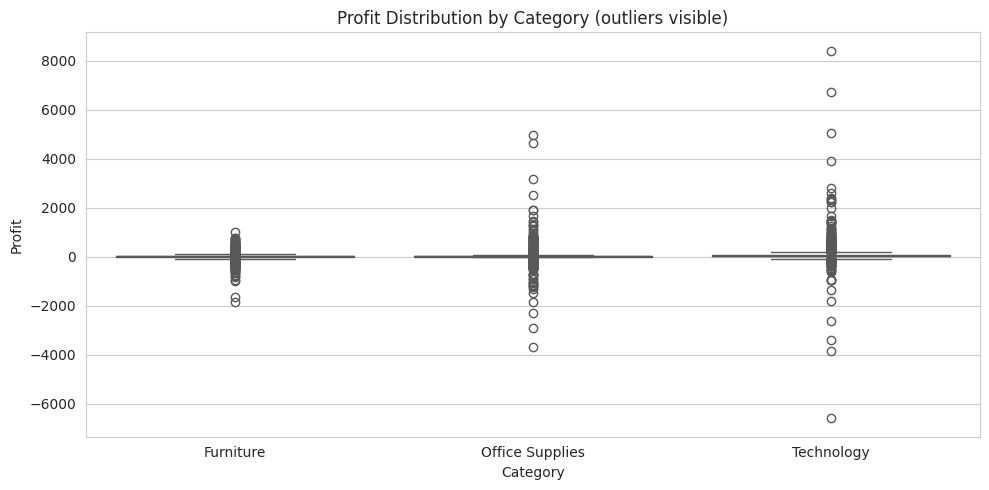

In [10]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='Category', y='Profit', palette='Set2')
plt.title('Profit Distribution by Category (outliers visible)')
plt.tight_layout()
plt.savefig('boxplot_profit_category.png', dpi=120)
plt.show()


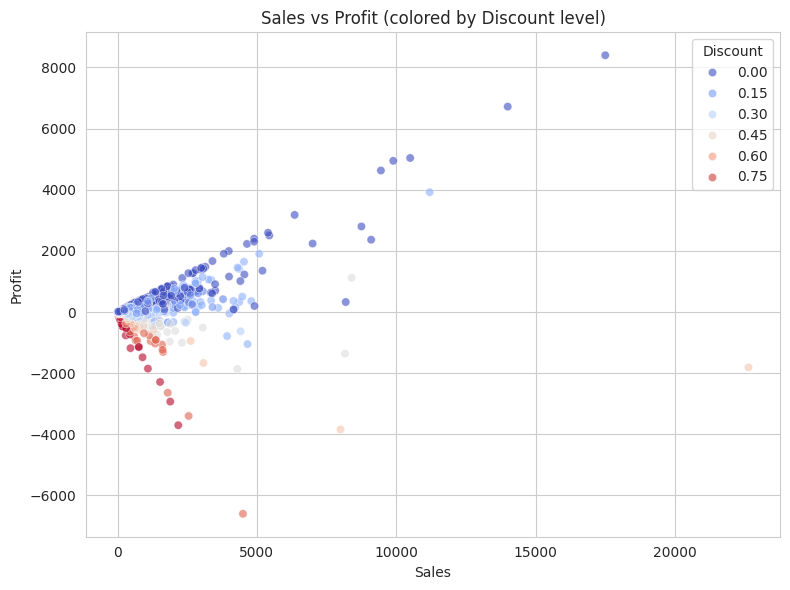

In [11]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Sales', y='Profit', hue='Discount', palette='coolwarm', alpha=0.6)
plt.title('Sales vs Profit (colored by Discount level)')
plt.tight_layout()
plt.savefig('scatter_sales_profit.png', dpi=120)
plt.show()


**Observation:** Furniture shows the widest spread of losses (many negative-profit outliers),
particularly Tables and Bookcases. The scatter plot shows that high-discount orders (warmer
colors) cluster in the negative-profit region even at high sales values — discounting is a major
driver of loss-making transactions.

## Step 8: Univariate, bivariate and multivariate analysis

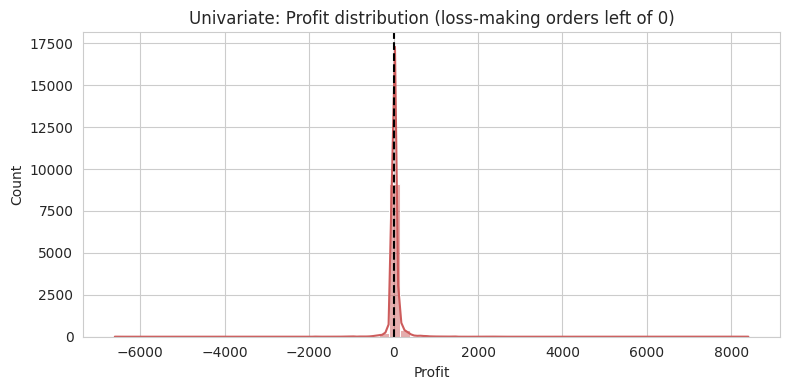

Loss-making orders: 1871 out of 10800 (17.3%)


In [12]:
# Univariate: Profit distribution
plt.figure(figsize=(8,4))
sns.histplot(df['Profit'], bins=60, kde=True, color='indianred')
plt.axvline(0, color='black', linestyle='--')
plt.title('Univariate: Profit distribution (loss-making orders left of 0)')
plt.tight_layout()
plt.savefig('univariate_profit.png', dpi=120)
plt.show()
print(f"Loss-making orders: {(df['Profit']<0).sum()} out of {len(df)} ({(df['Profit']<0).mean()*100:.1f}%)")


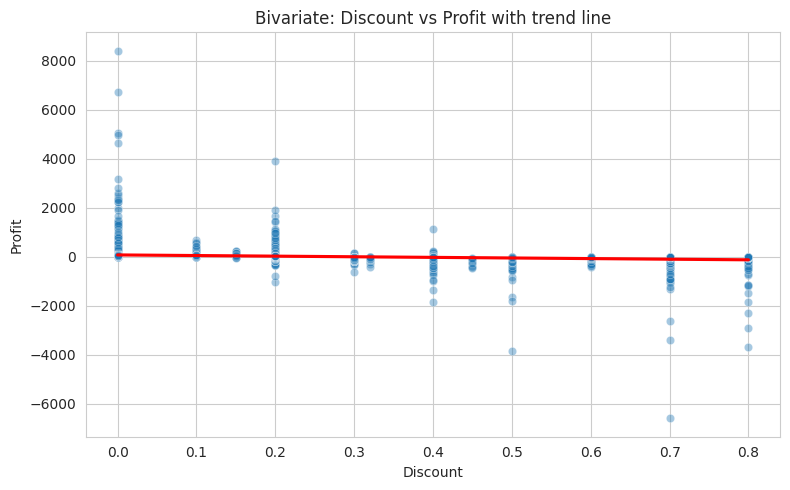

In [13]:
# Bivariate: Discount vs Profit
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.4)
sns.regplot(data=df, x='Discount', y='Profit', scatter=False, color='red')
plt.title('Bivariate: Discount vs Profit with trend line')
plt.tight_layout()
plt.savefig('bivariate_discount_profit.png', dpi=120)
plt.show()


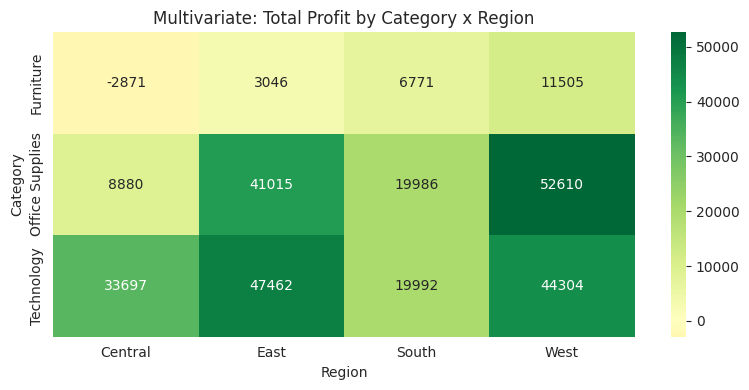

Region,Central,East,South,West
Category,,,,
Furniture,-2871.0494,3046.1658,6771.2061,11504.9503
Office Supplies,8879.9799,41014.5791,19986.3928,52609.8490
Technology,33697.4320,47462.0351,19991.8314,44303.6496


In [14]:
# Multivariate: Profit by Category & Region (pivot heatmap)
pivot = df.pivot_table(values='Profit', index='Category', columns='Region', aggfunc='sum')
plt.figure(figsize=(8,4))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn', center=0)
plt.title('Multivariate: Total Profit by Category x Region')
plt.tight_layout()
plt.savefig('multivariate_category_region.png', dpi=120)
plt.show()
pivot


**Observation:** Furniture is unprofitable specifically in the Central region, while Technology
is the strongest profit driver across almost every region. This three-way view (Category x Region
x Profit) reveals a pattern that neither the univariate nor the bivariate charts show on their own.

## Step 9: Key business observations

1. **Discounting hurts margins.** Profit correlates negatively with Discount; orders with discounts
   above ~30% are frequently loss-making regardless of sales value.
2. **Furniture is a problem category.** Tables and Bookcases post the most negative-profit outliers,
   dragging down overall category profitability, especially in the Central region.
3. **Technology drives profit.** Despite not having the highest order volume, Technology (particularly
   Copiers and Accessories) shows the strongest and most consistent profit contribution.
4. **Consumer segment dominates volume** but Corporate and Home Office segments show comparable or
   better profit-per-order in several sub-categories.
5. **Regional imbalance:** West and East regions outperform Central and South in both volume and profit.


## Step 10: Recommendations

- Cap discounts on Furniture (especially Tables) or renegotiate supplier costs — discounting beyond a
  threshold consistently produces losses.
- Double down on Technology marketing/inventory since it has the best profit-to-sales efficiency.
- Investigate Central region operations (Furniture in particular) — logistics or pricing may need
  region-specific correction.
- Use Corporate/Home Office segment insights to design targeted upsell offers that don't rely on deep
  discounting.
